# Experiment: SML2010 Dataset — Per-Layer gamma = 1/√(median_sqdist at each layer input)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample
import seaborn as sns

import torch
from torch.utils.data import Dataset,DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import psutil, os, sys
import resource  # Built-in, no pip install needed
import gc
import multiprocessing
import threading

import random



In [2]:
# =============================================
# Global Training Parameters
# =============================================
# Change these values once to apply to all algorithms
TRAINING_CONFIG = {
    'batch_size': 256,
    'max_epochs': 1000,
    'early_stop_window': 50,
    'lr': 1e-4,
    'momentum': 0.95,
    'weight_decay': 1e-3,
    'seed': 7199,
}

# =============================================
# Global Network Architecture Parameters
# =============================================
# Input dimension (determined by dataset)
INPUT_DIM = 15      # Number of features in dataset

# Hidden layer dimensions (shared across all models)
HIDDEN_DIM1 = 32    # First hidden layer dimension
HIDDEN_DIM2 = 64   # Second hidden layer dimension
HIDDEN_DIM3 = 16    # Third hidden layer dimension

# Results directory for this gamma-median run
RESULTS_DIR = 'sml_results_layer_gamma'
os.makedirs(RESULTS_DIR, exist_ok=True)


In [3]:
# Read header line to get column names
import re
with open('../../data/sml2010/NEW-DATA-1.T15.txt', 'r') as f:
    header_line = f.readline().strip()

# Extract column names from header (remove # and split by whitespace)
header_line = header_line.lstrip('#').strip()
column_names = re.split(r'\s+', header_line)

# Read data files with proper separator (multiple whitespaces) and skip header line
df1=pd.read_csv('../../data/sml2010/NEW-DATA-1.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
df2=pd.read_csv('../../data/sml2010/NEW-DATA-2.T15.txt', sep=r'\s+', skiprows=1, header=None, names=column_names)
tt=len(df1)
df=pd.concat([df1,df2],ignore_index=True)
df=df.drop(columns=['1:Date','2:Time','3:Temperature_Comedor_Sensor','5:Weather_Temperature','19:Exterior_Entalpic_1','20:Exterior_Entalpic_2','21:Exterior_Entalpic_turbo','24:Day_Of_Week']) 
display(df.head())
print(df.shape)

,4:Temperature_Habitacion_Sensor,6:CO2_Comedor_Sensor,7:CO2_Habitacion_Sensor,8:Humedad_Comedor_Sensor,9:Humedad_Habitacion_Sensor,10:Lighting_Comedor_Sensor,11:Lighting_Habitacion_Sensor,12:Precipitacion,13:Meteo_Exterior_Crepusculo,14:Meteo_Exterior_Viento,15:Meteo_Exterior_Sol_Oest,16:Meteo_Exterior_Sol_Est,17:Meteo_Exterior_Sol_Sud,18:Meteo_Exterior_Piranometro,22:Temperature_Exterior_Sensor,23:Humedad_Exterior_Sensor
0,17.8275,216.560,221.920,39.9125,42.4150,81.6650,113.520,0.0,623.360,1.42625,9690.24,12604.20,95436.8,758.880,18.1150,48.3750
1,18.1207,219.947,220.363,39.9267,42.2453,81.7413,113.605,0.0,623.211,1.59200,11022.00,10787.20,95436.8,762.069,18.4147,47.8080
2,18.4367,219.403,218.933,39.7720,42.2267,81.4240,113.600,0.0,622.656,1.89133,13960.50,9669.63,95398.6,766.251,18.8533,47.4320
3,18.7513,218.613,217.045,39.7760,42.0987,81.5013,113.344,0.0,622.571,1.82800,18511.20,9648.13,95360.3,766.037,19.2907,47.0240
4,19.0414,217.714,216.080,39.7757,42.0686,81.4657,113.034,0.0,622.400,2.36071,26349.00,9208.32,95354.9,762.743,19.7400,45.4743


(4137, 16)


In [4]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

data = pd.concat([y, x], axis=1)

train, calibration = train_test_split(data[:tt], test_size=0.5, random_state=1)
test = data[tt:]

train_y = train.iloc[:, 0].to_numpy()
train_x = train.iloc[:, 1:].to_numpy()

calibration_y = calibration.iloc[:, 0].to_numpy()
calibration_x = calibration.iloc[:, 1:].to_numpy()

test_y = test.iloc[:, 0].to_numpy()
test_x = test.iloc[:, 1:].to_numpy()

#x_scaler = preprocessing.MinMaxScaler()
x_scaler = preprocessing.StandardScaler()
train_x = x_scaler.fit_transform(train_x)   # fit on train only ✅
calibration_x = x_scaler.transform(calibration_x)
test_x = x_scaler.transform(test_x)

train_x.shape, calibration_x.shape, test_x.shape

nntrain_x = torch.from_numpy(train_x).float()
nntrain_y = torch.squeeze(torch.from_numpy(train_y).float()) 
nntest_x= torch.from_numpy(test_x).float()
nntest_y = torch.squeeze(torch.from_numpy(test_y).float())


In [5]:
# ── Per-layer median-distance heuristic for gamma ───────────────────────────
# For RFF with W ~ N(0, gamma^2 I), the kernel is exp(-gamma^2/2 * ||x-y||^2).
# Matching the median heuristic: gamma = 1 / sqrt(median_sqdist).
#
# Theoretically, each RFF layer should use a gamma matched to the distribution
# of ITS OWN inputs, not the original data. We provide:
#   - _compute_layer_gamma(X): helper that computes gamma from any data matrix X
#   - gamma_median: gamma for layer 1 (from train_x), also used by RF+Ridge
# Per-layer gammas for MLKM/ResKernelNet are computed inside their run functions
# using a random-init forward pass to approximate each layer's input distribution.

def _compute_layer_gamma(X_np):
    """Compute median-heuristic gamma from a numpy array X (n x d).
    Uses a subsample of up to 2000 rows to keep O(n^2) cost manageable."""
    X = X_np[:2000]  # subsample if large
    dists = np.sum((X[None,:,:] - X[:,None,:])**2, axis=-1)
    flat  = dists[np.triu_indices(len(X), k=1)]
    med_sq = float(np.median(flat))
    if med_sq < 1e-12:
        return 1.0  # fallback: data is degenerate
    print(float(1.0 / np.sqrt(med_sq)))
    return float(1.0 / np.sqrt(med_sq))

# Layer-1 gamma (from raw input features) — also used by RF+Ridge
gamma_median = _compute_layer_gamma(train_x)

print(f'gamma_l1 (from train_x, d={train_x.shape[1]}):  {gamma_median:.6f}')
print('Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.')


0.20053414536259034
gamma_l1 (from train_x, d=15):  0.200534
Per-layer gammas for MLKM/ResKernelNet will be printed when each model runs.


In [6]:

print("NaNs in train_x:", np.isnan(train_x).any())
print("NaNs in calibration_x:", np.isnan(calibration_x).any())
print("NaNs in test_x:", np.isnan(test_x).any())

print("NaNs per column in train_x:", np.isnan(train_x).sum(axis=0))
print("NaNs per column in test_x:", np.isnan(test_x).sum(axis=0))
print("Rows in train_x with any NaN:", np.isnan(train_x).any(axis=1).sum())
print("Rows in test_x with any NaN:", np.isnan(test_x).any(axis=1).sum())


NaNs in train_x: False
NaNs in calibration_x: False
NaNs in test_x: False
NaNs per column in train_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
NaNs per column in test_x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Rows in train_x with any NaN: 0
Rows in test_x with any NaN: 0


In [7]:

class mydataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y
        self._len = len(x)

    def __getitem__(self, item): 
        return self._x[item], self._y[item]

    def __len__(self):
        return self._len

In [8]:
GLOBAL_SEED = 7199   # or any integer you choose

def set_global_seed(seed: int):
    if seed is None:
        seed = GLOBAL_SEED
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
def measure_time(func, *args, **kwargs):
    """
    Measure wall-clock time of func(*args, **kwargs).
    Returns (result, runtime_in_seconds).
    """
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    return result, (t1 - t0)


def measure_memory_cpu(func, *args, **kwargs):
    """
    Measure CPU memory during func() execution using a background polling thread.
    Returns: (result, delta_mb, peak_mb)
      - delta_mb: net RSS change (after - before). Can be negative if GC reclaims
                  memory during execution, so treat as informational only.
      - peak_mb:  peak RSS *increase* above baseline during execution (always >= 0).
                  Captured via a 50ms polling thread — the reliable metric.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss

    peak_rss = [mem_before]
    stop_event = threading.Event()

    def _monitor():
        while not stop_event.is_set():
            try:
                cur = process.memory_info().rss
                if cur > peak_rss[0]:
                    peak_rss[0] = cur
            except Exception:
                pass
            stop_event.wait(0.05)

    monitor_thread = threading.Thread(target=_monitor, daemon=True)
    monitor_thread.start()

    result = func(*args, **kwargs)

    mem_after = process.memory_info().rss
    stop_event.set()
    monitor_thread.join()

    if mem_after > peak_rss[0]:
        peak_rss[0] = mem_after

    delta_mb = (mem_after - mem_before) / 1024**2
    peak_mb  = (peak_rss[0] - mem_before) / 1024**2

    return result, delta_mb, peak_mb




def measure_memory_gpu(func, *args, **kwargs):
    """
    Measure peak GPU memory allocated during func().
    Returns: (result, peak_MB or None)
    """
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None

    torch.cuda.reset_peak_memory_stats()

    result = func(*args, **kwargs)

    peak_bytes = torch.cuda.max_memory_allocated()
    peak_mb = peak_bytes / 1024**2

    return result, peak_mb


In [9]:

def conformal_prediction_split(
    net,
    device,
    calibration_x,
    calibration_y,
    test_x,
    test_y,
    alpha=0.05
):
    """
    Standard split conformal prediction for regression.

    This follows the notation:
        R_i = |y_i - f_hat(x_i)|,  i in A_2

    and constructs prediction intervals:
        [f_hat(x) - q_hat, f_hat(x) + q_hat]

    Args:
        net: trained neural network
        device: torch device
        calibration_x, calibration_y: calibration set (A_2)
        test_x, test_y: test set
        alpha: miscoverage level, e.g. 0.05 for 95% coverage

    Returns:
        coverage: empirical coverage on test set
        avg_interval_length: average interval length on test set
        q_hat: conformal quantile used as half-width
    """
    net.eval()

    # ----------------------------
    # Step 1: Compute calibration scores
    # R_i = |y_i - f_hat(x_i)|
    # ----------------------------
    scores = []

    with torch.no_grad():
        for i in range(len(calibration_x)):
            x0 = torch.from_numpy(calibration_x[i:i+1]).float().to(device)
            pred = net(x0)

            # convert prediction to scalar
            pred_val = pred.detach().cpu().numpy().reshape(-1)[0]

            score = np.abs(calibration_y[i] - pred_val)
            scores.append(score)

    scores = np.array(scores)

    if len(scores) == 0:
        return 0.0, float("inf"), float("nan")

    # ----------------------------
    # Step 2: Compute conformal quantile q_hat
    # q_hat = ceil((m+1)(1-alpha))th smallest score
    # where m = len(calibration set)
    # ----------------------------
    m = len(scores)
    sorted_scores = np.sort(scores)

    k = int(np.ceil((m + 1) * (1 - alpha)))
    k = min(max(k, 1), m)  

    q_hat = sorted_scores[k - 1]  

    # ----------------------------
    # Step 3: Apply to test set
    # interval = [f_hat(x) - q_hat, f_hat(x) + q_hat]
    # ----------------------------
    covered = 0
    lengths = []

    with torch.no_grad():
        for i in range(len(test_x)):
            x0 = torch.from_numpy(test_x[i:i+1]).float().to(device)
            pred = net(x0)

            pred_val = pred.detach().cpu().numpy().reshape(-1)[0]

            lower = pred_val - q_hat
            upper = pred_val + q_hat

            lengths.append(upper - lower)

            if lower <= test_y[i] <= upper:
                covered += 1

    coverage = covered / len(test_x) if len(test_x) > 0 else 0.0
    avg_interval_length = np.mean(lengths) if len(lengths) > 0 else float("inf")

    return coverage, avg_interval_length, q_hat

### Random Feature

In [10]:
def sample_1d(pdf, gamma):
    if pdf=='G':
        w=torch.randn(1)*gamma
        return w
    elif pdf=='L':
        w=torch.distributions.laplace.Laplace(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    elif pdf=='C':
        w=torch.distributions.cauchy.Cauchy(torch.tensor([0.0]), torch.tensor([1.0])).sample()*gamma
        return w
    
def sample(pdf, gamma, d):
    return torch.tensor([sample_1d(pdf, gamma) for _ in range(d)])

class RandomFourierFeature:
    """Random Fourier Feature
    Parameters
    ----------
    d : int
        Input space dimension
    D : int
        Feature space dimension
    W : shape (D,d)
    b : shape (D)
    kernel : char
        Kernel to use; 'G', 'L', or 'C'
    gamma : float
        pdf parameter
    """

    def __init__(self, d, D, W=None, b=None, kernel='G', gamma=1):

        self.d = d
        self.D = D
        self.gamma = gamma

        kernel = kernel.upper()
        if kernel not in ['G', 'L', 'C']:
            raise Exception('Invalid Kernel')
        self.kernel = kernel

        if W is None or b is None:
            self.create()
        else:
            self.__load(W, b)

    def __load(self, W, b):
        """Load from existing Arrays"""

        self.W = W.reshape([self.D, self.d])
        self.b = b
    

    def create(self):
        """Create a d->D fourier random feature"""

        self.b = torch.rand(self.D)*2*torch.pi
        self.W = sample(self.kernel, self.gamma, self.d*self.D).reshape(self.D,self.d)

    def transform(self, x):
        """Transform a vector using this feature
        Parameters
        ----------
        x : (shape=(n,d))
            to transform; must be single dimension vector
        Returns
        -------
        x : (shape=(n,D))
            Feature space transformation of x
        """
        #print(self.W.shape,self.b.reshape(-1,1).shape,x.shape)
        #print((self.W @ x.T).shape)
       
        result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1))) 
        #print(result.T.shape)
        return result.T

In [11]:
def run_rf_ridge(train_x, train_y, test_x, test_y,
                 calibration_x, calibration_y,
                 D=500, gamma=None, seed=7199):
    """
    Train RF + Ridge and return (train_mse, test_mse).
    No timing or memory in here.
    """
    g = gamma if gamma is not None else gamma_median
    set_global_seed(seed)
    rff = RandomFourierFeature(d=train_x.shape[1], D=D,
                               kernel='G', gamma=g)

    total_x = np.vstack((train_x, calibration_x))
    total_y = np.hstack((train_y, calibration_y))

    # Random Fourier Features
    total_feature = rff.transform(total_x)
    test_feature  = rff.transform(test_x)

    # Ridge + CV
    model = Ridge()
    param_grid = {'alpha': [1e-4,1e-3,1e-2,1e-1,1]}
    kf = KFold(n_splits=5, shuffle=True)

    grid_search = GridSearchCV(model, param_grid, cv=kf)
    grid_search.fit(total_feature, total_y)

    best_model = grid_search.best_estimator_
    rf_pred_total = best_model.predict(total_feature)
    rf_pred_test  = best_model.predict(test_feature)

    train_mse = mean_squared_error(total_y, rf_pred_total)
    test_mse  = mean_squared_error(test_y, rf_pred_test)
    return train_mse, test_mse


def rf_core():
    return run_rf_ridge(train_x, train_y, test_x, test_y,
                        calibration_x, calibration_y,
                        D=500, gamma=0.4, seed=7199)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

(rf_result, rf_delta_cpu_mb, rf_peak_cpu_mb), rf_time = measure_time(
    lambda: measure_memory_cpu(rf_core)
)

rf_train_mse, rf_test_mse = rf_result

print("RF train MSE:", rf_train_mse)
print("RF test MSE:",  rf_test_mse)
print("RF runtime (s):", rf_time)
print("RF CPU Δ memory (MB):", rf_delta_cpu_mb)
print("RF CPU peak (MB):", rf_peak_cpu_mb)


/var/folders/z7/p968ccvd4d9c27v5n0y0qbyw0000gn/T/ipykernel_55131/462636501.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  result=torch.sqrt(torch.tensor([2.0/self.D])) * torch.cos( self.W @ x.T  + (self.b.reshape(-1,1) @ torch.ones(len(x)).reshape(1,-1)))


RF train MSE: 0.12334928225495893
RF test MSE: 3.445907014374089
RF runtime (s): 0.47675514221191406
RF CPU Δ memory (MB): 36.453125
RF CPU peak (MB): 36.453125


## 1. DNN

In [12]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM1)
        self.fc2 = nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2)
        self.fc3 = nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)





#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0)

def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256,
            max_epochs=1000,
            early_stop_window=50,
            lr=1e-4,
            momentum=0.9,
            weight_decay=1e-2,
            device=None,
            verbose=False,
            seed=7199):
    """
    Train the DNN and return (train_mse, test_mse, num_epochs_run).
    No timing or memory measurement inside.
    """

    # reproducibility
    set_global_seed(seed)

    # choose device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # numpy -> tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),
                              batch_size=batch_size, shuffle=True)
    # test_loader  = DataLoader(mydataset(nntest_x, nntest_y),
    #                           batch_size=batch_size, shuffle=False)

    # model, loss, optimizer
    net = Net().to(device)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(),
                          lr=lr,
                          momentum=momentum,
                          weight_decay=weight_decay)

    dnn_trainloss = []
    dnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # evaluate full train & test MSE (like your original code)
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            dnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            dnn_testloss.append(test_mse)

        # early stopping: same idea as your code
        if epoch > early_stop_window:
            if float(dnn_trainloss[-1]) > max(dnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch:4d}  train MSE: {dnn_trainloss[-1]:.6f}  "
                  f"test MSE: {dnn_testloss[-1]:.6f}")

    num_epochs_run = len(dnn_trainloss)
    final_train_mse = dnn_trainloss[-1]
    final_test_mse  = dnn_testloss[-1]

    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, dnn_trainloss, dnn_testloss, device


In [13]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# GPU wrapper inside, CPU wrapper around it, then time
((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_peak_cpu_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)


dnn_train_mse, dnn_test_mse, dnn_epochs, dnn_net, dnn_optimizer, dnn_trainloss, dnn_testloss, dnn_device = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN time:", dnn_time)
print("DNN peak GPU (MB):", dnn_peak_gpu_mb)
print("DNN CPU Δ (MB):", dnn_delta_cpu_mb)
print("DNN CPU peak (MB):", dnn_peak_cpu_mb)


DNN train MSE: 0.27717878041224747
DNN test MSE: 1.2927815464375387
DNN time: 7.968713283538818
DNN peak GPU (MB): None
DNN CPU Δ (MB): 66.84375
DNN CPU peak (MB): 66.84375


## 2. Resnet

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(outfeatures,outfeatures)
        self.skip = nn.Identity() if infeatures == outfeatures else nn.Linear(infeatures, outfeatures)

    
    def forward(self, x):
        identity = self.skip(x)
        y = F.relu(self.fc1(x))
        y = self.fc2(y)
        return identity + y


class ResNet(nn.Module): 
    def __init__(self):
        super(ResNet, self).__init__()
        self.rblock1 = ResidualBlock(INPUT_DIM, HIDDEN_DIM1)
        self.rblock2 = ResidualBlock(HIDDEN_DIM1, HIDDEN_DIM2)
        self.rblock3 = ResidualBlock(HIDDEN_DIM2, HIDDEN_DIM3)
        self.fc4 = nn.Linear(HIDDEN_DIM3, 1)
    
 
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        x = self.rblock3(x)
        return self.fc4(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=-0.1,b=0.1)
        m.bias.data.fill_(0)

In [15]:
def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):
    """
    Train a ResNet on tabular input and return:
        (train_mse, test_mse, num_epochs_run)
    No timing or memory measurements inside.
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy → Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )

    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)      # keep your initialization

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss  = []
    for epoch in range(max_epochs):

        # ---- Training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        # ---- Evaluation ----
        net.eval()
        with torch.no_grad():
            # full train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            # full test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ---- Early Skipping ----
        if epoch > early_stop_window:
            if res_trainloss[-1] > max(res_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ---- Optional Printing ----
        if verbose and epoch % 50 == 0:
            print(f"""epoch {epoch}
                Train MSE: {train_mse}
                Test  MSE: {test_mse}
            """)

    # final metrics
    num_epochs_run = len(res_trainloss)
    final_train_mse = res_trainloss[-1]
    final_test_mse  = res_testloss[-1]
    
    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, res_trainloss, res_testloss, device


In [16]:
def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((res_result, res_peak_gpu), res_delta_cpu, res_peak_cpu), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs, res_net, res_optimizer, res_trainloss, res_testloss, res_device = res_result

print("ResNet Train MSE:", res_train_mse)
print("ResNet Test  MSE:", res_test_mse)
print("ResNet Epochs:", res_epochs)
print("ResNet Time:", res_time)
print("ResNet CPU ΔMB:", res_delta_cpu)
print("ResNet CPU peak (MB):", res_peak_cpu)
print("ResNet GPU peak MB:", res_peak_gpu)



ResNet Train MSE: 0.18916349735685725
ResNet Test  MSE: 1.5271751958173148
ResNet Epochs: 1000
ResNet Time: 10.568483829498291
ResNet CPU ΔMB: -220.734375
ResNet CPU peak (MB): 0.8125
ResNet GPU peak MB: None


## 2.5 DKL (NN feature extractor + GP)


In [17]:
import gpytorch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1) feature extractor
class DKLFeatureExtractor(torch.nn.Module):
    def __init__(self, in_dim=INPUT_DIM):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, HIDDEN_DIM1),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM2, HIDDEN_DIM3),
            torch.nn.ReLU(),
            torch.nn.Linear(HIDDEN_DIM3, 2),  
        )
    def forward(self, x):
        return self.net(x)

# 2) DKL model = ExactGP + feature extractor
class DKLExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor):
        super().__init__(train_x, train_y, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        
    def forward(self, x):
        z = self.feature_extractor(x)
        mean_x = self.mean_module(z)
        covar_x = self.covar_module(z)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def run_dkl(train_x, train_y, test_x, test_y, training_iter=300, seed=7199):
    """Train DKL and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    
    # Initialize model
    dkl_likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    feat = DKLFeatureExtractor(in_dim=train_x_t.shape[1]).to(device)
    dkl_model = DKLExactGP(train_x_t, train_y_t, dkl_likelihood, feat).to(device)
    
    # Train
    dkl_model.train()
    dkl_likelihood.train()
    
    optimizer = torch.optim.Adam([
        {'params': dkl_model.feature_extractor.parameters(), 'lr': 1e-3},
        {'params': dkl_model.covar_module.parameters()},
        {'params': dkl_model.mean_module.parameters()},
        {'params': dkl_likelihood.parameters()},
    ], lr=0.05)
    
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(dkl_likelihood, dkl_model)
    
    for i in range(training_iter):
        optimizer.zero_grad()
        output = dkl_model(train_x_t)
        loss = -mll(output, train_y_t)
        loss.backward()
        optimizer.step()
    
    # Eval
    dkl_model.eval()
    dkl_likelihood.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_train = dkl_likelihood(dkl_model(train_x_t)).mean
        pred_test = dkl_likelihood(dkl_model(test_x_t)).mean
    
    train_mse = mean_squared_error(train_y, pred_train.detach().cpu().numpy())
    test_mse = mean_squared_error(test_y, pred_test.detach().cpu().numpy())
    
    return train_mse, test_mse


def dkl_core():
    return run_dkl(train_x, train_y, test_x, test_y)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((dkl_result, dkl_peak_gpu), dkl_delta_cpu, dkl_peak_cpu), dkl_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dkl_core)
    )
)

dkl_train_mse, dkl_test_mse = dkl_result

print("DKL Train MSE:", dkl_train_mse)
print("DKL Test  MSE:", dkl_test_mse)
print("DKL Time (s):", dkl_time)
print("DKL CPU Δ (MB):", dkl_delta_cpu)
print("DKL CPU peak (MB):", dkl_peak_cpu)
print("DKL GPU peak (MB):", dkl_peak_gpu)


DKL Train MSE: 0.08436301066547508
DKL Test  MSE: 2.5849192054512495
DKL Time (s): 6.386907339096069
DKL CPU Δ (MB): 37.015625
DKL CPU peak (MB): 37.015625
DKL GPU peak (MB): None


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


## 2.6 DGP baseline（Deep Gaussian Process）

In [18]:
# ----- DGP building blocks -----
class DGPLayer(gpytorch.models.deep_gps.DeepGPLayer):
    def __init__(self, input_dims, output_dims, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy, input_dims, output_dims)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def run_dgp(train_x, train_y, test_x, test_y, 
            training_iter=1000, batch_size=256, num_inducing=128, hidden_dim=5, seed=7199):
    """Train Deep GP and return (train_mse, test_mse)"""
    set_global_seed(seed)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    train_x_t = torch.from_numpy(train_x).float().to(device)
    train_y_t = torch.from_numpy(train_y).float().squeeze().to(device)
    test_x_t = torch.from_numpy(test_x).float().to(device)
    
    # Build model (inline TwoLayerDGP to avoid global dependency)
    class TwoLayerDGP(gpytorch.models.deep_gps.DeepGP):
        def __init__(self, train_x_t, num_inducing, hidden_dim):
            super().__init__()
            inducing_1 = train_x_t[torch.randperm(train_x_t.size(0))[:num_inducing]]
            inducing_2 = torch.randn(num_inducing, hidden_dim).to(device)

            self.hidden_layer = DGPLayer(
                input_dims=train_x_t.shape[1],
                output_dims=hidden_dim,
                inducing_points=inducing_1
            )
            self.output_layer = DGPLayer(
                input_dims=hidden_dim,
                output_dims=None,
                inducing_points=inducing_2
            )
            self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)

        def forward(self, inputs):
            hidden_rep = self.hidden_layer(inputs)
            output = self.output_layer(hidden_rep)
            return output

        def predict(self, x):
            self.eval()
            self.likelihood.eval()
            with torch.no_grad(), gpytorch.settings.num_likelihood_samples(16):
                preds = self.likelihood(self(x))
                return preds.mean.mean(dim=0)
    
    dgp_model = TwoLayerDGP(train_x_t, num_inducing, hidden_dim).to(device)
    dgp_model.train()
    dgp_model.likelihood.train()
    
    optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)
    elbo = gpytorch.mlls.DeepApproximateMLL(
        gpytorch.mlls.VariationalELBO(dgp_model.likelihood, dgp_model, num_data=train_x_t.size(0))
    )
    
    for i in range(training_iter):
        perm = torch.randperm(train_x_t.size(0), device=device)
        for j in range(0, train_x_t.size(0), batch_size):
            idx = perm[j:j+batch_size]
            optimizer.zero_grad()
            output = dgp_model(train_x_t[idx])
            loss = -elbo(output, train_y_t[idx])
            loss.backward()
            optimizer.step()
    
    # Eval
    pred_train = dgp_model.predict(train_x_t).detach().cpu().numpy()
    pred_test = dgp_model.predict(test_x_t).detach().cpu().numpy()
    
    train_mse = mean_squared_error(train_y, pred_train)
    test_mse = mean_squared_error(test_y, pred_test)
    
    return train_mse, test_mse


def dgp_core():
    return run_dgp(train_x, train_y, test_x, test_y)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((dgp_result, dgp_peak_gpu), dgp_delta_cpu, dgp_peak_cpu), dgp_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dgp_core)
    )
)

dgp_train_mse, dgp_test_mse = dgp_result

print("DGP Train MSE:", dgp_train_mse)
print("DGP Test  MSE:", dgp_test_mse)
print("DGP Time (s):", dgp_time)
print("DGP CPU Δ (MB):", dgp_delta_cpu)
print("DGP CPU peak (MB):", dgp_peak_cpu)
print("DGP GPU peak (MB):", dgp_peak_gpu)


DGP Train MSE: 0.17170034420740637
DGP Test  MSE: 2.3304834408975137
DGP Time (s): 173.17970085144043
DGP CPU Δ (MB): 131.8125
DGP CPU peak (MB): 131.8125
DGP GPU peak (MB): None


## 3. MLKM

In [19]:
# D1, D2, D3 now passed as parameters to run_mlkm for flexibility

def run_mlkm(train_x, train_y, test_x, test_y,
             D1=500, D2=500, D3=500,  # RFF feature dimensions
             batch_size=256,
             max_epochs=1000,
             early_stop_window=50,
             lr=1e-4,
             momentum=0.95,
             weight_decay=1e-3,
             device=None,
             verbose=False,
             seed=7199):

    # -----------------------
    # 1. Reproducibility
    # -----------------------
    set_global_seed(seed)

    # Device

    # -----------------------
    # 2. NumPy -> Tensors
    # -----------------------
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x = torch.from_numpy(test_x).float()
    # nntest_y = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )
    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # -----------------------
    # 3. Per-layer gamma computation (median heuristic on each layer's input)
    # -----------------------
    # Layer 1: input is train_x
    gamma_l1 = _compute_layer_gamma(train_x)

    # Layer 2: input is fc1(rff1(train_x)) with a temporary random-init layer
    with torch.no_grad():
        _rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
        _fc1  = nn.Linear(D1, HIDDEN_DIM1)           # random-init weights
        _h1   = _fc1(_rff1.transform(
                    torch.from_numpy(train_x).float()
                )).numpy()
    gamma_l2 = _compute_layer_gamma(_h1)

    # Layer 3: input is fc2(rff2(h1)) with another temporary random-init layer
    with torch.no_grad():
        _rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
        _fc2  = nn.Linear(D2, HIDDEN_DIM2)
        _h2   = _fc2(_rff2.transform(
                    torch.from_numpy(_h1).float()
                )).numpy()
    gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  MLKM per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    # -----------------------
    # 4. Random Fourier Features with per-layer gammas
    # -----------------------
    rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)



    # -----------------------
    # 5. Define KernelNet inside function to capture rff1, rff2, rff3
    # -----------------------
    class KernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            # self.fc1 = nn.Linear(HIDDEN_DIM1 * 20, HIDDEN_DIM1)
            self.fc1 = nn.Linear(D1, HIDDEN_DIM1)   # -> 16
            self.fc2 = nn.Linear(D2, HIDDEN_DIM2)   # -> 64
            self.fc3 = nn.Linear(D3, HIDDEN_DIM3)   # -> 16
            self.out = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.fc1(rff1.transform(x))   # INPUT -> D1 -> 16
            x = self.fc2(rff2.transform(x))   # 16 -> D2 -> 64
            x = self.fc3(rff3.transform(x))   # 64 -> D3 -> 16
            return self.out(x)                # 16 -> 1
    # 6. Model, Loss, Optimizer
    # -----------------------
    net = KernelNet().to(device)
    net.apply(init_weights)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # -----------------------
    # 7. Training Loop
    # -----------------------
    kernelnn_trainloss = []
    kernelnn_testloss = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # ---- Evaluation (train + test MSE) ----
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            kernelnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            kernelnn_testloss.append(test_mse)

        # ---- Early stopping ----
        if epoch > early_stop_window:
            if kernelnn_trainloss[-1] > max(kernelnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    num_epochs_run = len(kernelnn_trainloss)
    final_train_mse = kernelnn_trainloss[-1]
    final_test_mse = kernelnn_testloss[-1]

    # Return additional outputs for conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, kernelnn_trainloss, kernelnn_testloss, device

In [20]:
def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_peak_cpu), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

# Unpack all results including model/optimizer for conformal prediction
mlkm_train_mse, mlkm_test_mse, mlkm_epochs, mlkm_net, mlkm_optimizer, mlkm_trainloss, mlkm_testloss, mlkm_device = mlkm_result


0.20053414536259034
7.6528390027146065
5.525991160627398


In [21]:
print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test  MSE:", mlkm_test_mse)
print("MLKM epochs run:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM CPU ΔMB:", mlkm_delta_cpu)
print("MLKM CPU peak (MB):", mlkm_peak_cpu)
print("MLKM GPU peak MB:", mlkm_peak_gpu)


MLKM train MSE: 0.06770217500254253
MLKM test  MSE: 9.167686298998227
MLKM epochs run: 404
MLKM time: 10.927066087722778
MLKM CPU ΔMB: 926.125
MLKM CPU peak (MB): 926.125
MLKM GPU peak MB: None


## 4. Residual multilayer learning

In [23]:
def run_reskernelnet(train_x, train_y, test_x, test_y,
                     batch_size=128,
                     D1=500, D2=None, D3=None,  # D2, D3 auto-set to HIDDEN_DIM1, HIDDEN_DIM2
                     max_epochs=1000,
                     early_stop_window=50,
                     lr=1e-4,
                     momentum=0.9,
                     weight_decay=1e-2,
                     device=None,
                     verbose=False,
                     seed=7199):
    """
    Train ResKernelNet and return (train_mse, test_mse, num_epochs_run)
    Note: D2 and D3 must equal HIDDEN_DIM1 and HIDDEN_DIM2 for residual connections
    """
    set_global_seed(seed)
    
    # D2 and D3 must match hidden dims for residual connections
    if D2 is None:
        D2 = HIDDEN_DIM1
    if D3 is None:
        D3 = HIDDEN_DIM2
    
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # Convert to tensors
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    
    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y), batch_size=batch_size, shuffle=True)
    
    # Per-layer gamma computation (median heuristic on each layer's input)
    # Layer 1: input is train_x
    gamma_l1 = _compute_layer_gamma(train_x)

    # Layer 2: input is b1(train_x) = A1(train_x) + W1(rff1(train_x)) at random init
    with torch.no_grad():
        _rff1  = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
        _A1    = nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)  # projection if dims differ
        _W1    = nn.Linear(D1, HIDDEN_DIM1)
        _Delta1= nn.Linear(INPUT_DIM, HIDDEN_DIM1, bias=False)
        nn.init.zeros_(_Delta1.weight)
        _x_t   = torch.from_numpy(train_x).float()
        _h1    = (_A1(_x_t) + _Delta1(_x_t) + _W1(_rff1.transform(_x_t))).numpy()
    gamma_l2 = _compute_layer_gamma(_h1)

    # Layer 3: input is b2(h1) — block 2: HIDDEN_DIM1 -> HIDDEN_DIM2
    with torch.no_grad():
        _rff2  = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
        # Skip projection: A2 = Linear(d_in, d_out) when dims differ (mirrors ResKernelBlock)
        _A2    = (nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
                  if HIDDEN_DIM1 != HIDDEN_DIM2 else nn.Identity())
        _W2    = nn.Linear(D2, HIDDEN_DIM2)
        _Delta2= nn.Linear(HIDDEN_DIM1, HIDDEN_DIM2, bias=False)
        nn.init.zeros_(_Delta2.weight)
        _h1_t  = torch.from_numpy(_h1).float()
        # A2(x) + Delta2(x) + W2(rff2(x))  — Delta2 is zero, so effectively A2(x) + W2(rff2(x))
        _h2    = (_A2(_h1_t) + _Delta2(_h1_t) + _W2(_rff2.transform(_h1_t))).numpy()
    gamma_l3 = _compute_layer_gamma(_h2)

    if verbose:
        print(f'  RKN per-layer gammas: L1={gamma_l1:.4f}  L2={gamma_l2:.4f}  L3={gamma_l3:.4f}')

    # Random Fourier Features with per-layer gammas
    rff1 = RandomFourierFeature(INPUT_DIM, D1, kernel='G', gamma=gamma_l1)
    rff2 = RandomFourierFeature(HIDDEN_DIM1, D2, kernel='G', gamma=gamma_l2)
    rff3 = RandomFourierFeature(HIDDEN_DIM2, D3, kernel='G', gamma=gamma_l3)
    

            

    class ResKernelBlock(nn.Module):
        def __init__(self, d_in, d_phi, d_out, rff):
            super().__init__()
            self.rff = rff                      # phi(x) in R^{d_phi}
            self.W = nn.Linear(d_phi, d_out)    # W_l
            self.A = nn.Identity() if d_in == d_out else nn.Linear(d_in, d_out, bias=False)  # P_l

            # Optional Δ_l initialized to 0 (learnable perturbation)
            self.Delta = nn.Linear(d_in, d_out, bias=False)
            nn.init.zeros_(self.Delta.weight)

        def forward(self, x):
            skip = self.A(x) + self.Delta(x)        # A_l x  (≈ projection/identity)
            main = self.W(self.rff.transform(x))    # W_l phi_l(x)
            return skip + main


    class ResKernelNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.b1 = ResKernelBlock(INPUT_DIM,   D1, HIDDEN_DIM1, rff1)
            self.b2 = ResKernelBlock(HIDDEN_DIM1, D2, HIDDEN_DIM2, rff2)
            self.b3 = ResKernelBlock(HIDDEN_DIM2, D3, HIDDEN_DIM3, rff3)
            self.out = nn.Linear(HIDDEN_DIM3, 1)

        def forward(self, x):
            x = self.b1(x)
            x = self.b2(x)
            x = self.b3(x)
            return self.out(x)
    
    # Initialize model
    net = ResKernelNet().to(device)
    torch.manual_seed(1)
    
    criterion = nn.MSELoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    
    reskernel_trainloss = []
    reskernel_testloss = []
    
    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
        
        # Evaluate
        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            reskernel_trainloss.append(train_mse)
            
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            reskernel_testloss.append(test_mse)
        
        # Early stopping
        if epoch > early_stop_window:
            if reskernel_trainloss[-1] > max(reskernel_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch}: Train MSE={train_mse:.6f}, Test MSE={test_mse:.6f}")
    
    num_epochs_run = len(reskernel_trainloss)
    final_train_mse = reskernel_trainloss[-1]
    final_test_mse = reskernel_testloss[-1]
    
    # Return training history and model for plotting and conformal prediction
    return final_train_mse, final_test_mse, num_epochs_run, net, optimizer, reskernel_trainloss, reskernel_testloss, device


def reskernelnet_core():
    return run_reskernelnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)

# Clear memory before measurement
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Measure with wrappers
((rkn_result, rkn_peak_gpu), rkn_delta_cpu, rkn_peak_cpu), rkn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(reskernelnet_core)
    )
)

rkn_train_mse, rkn_test_mse, rkn_epochs, rkn_net, rkn_optimizer, rkn_trainloss, rkn_testloss, rkn_device = rkn_result

print("ResKernelNet Train MSE:", rkn_train_mse)
print("ResKernelNet Test  MSE:", rkn_test_mse)
print("ResKernelNet Epochs:", rkn_epochs)
print("ResKernelNet Time (s):", rkn_time)
print("ResKernelNet CPU Δ (MB):", rkn_delta_cpu)
print("ResKernelNet CPU peak (MB):", rkn_peak_cpu)
print("ResKernelNet GPU peak (MB):", rkn_peak_gpu)

0.20053414536259034
0.23534221015174064
0.27365683527662676
ResKernelNet Train MSE: 0.2692736107500841
ResKernelNet Test  MSE: 1.2314133897736494
ResKernelNet Epochs: 1000
ResKernelNet Time (s): 19.079272031784058
ResKernelNet CPU Δ (MB): 970.65625
ResKernelNet CPU peak (MB): 985.421875
ResKernelNet GPU peak (MB): None


## Training Curves: Epoch vs MSE


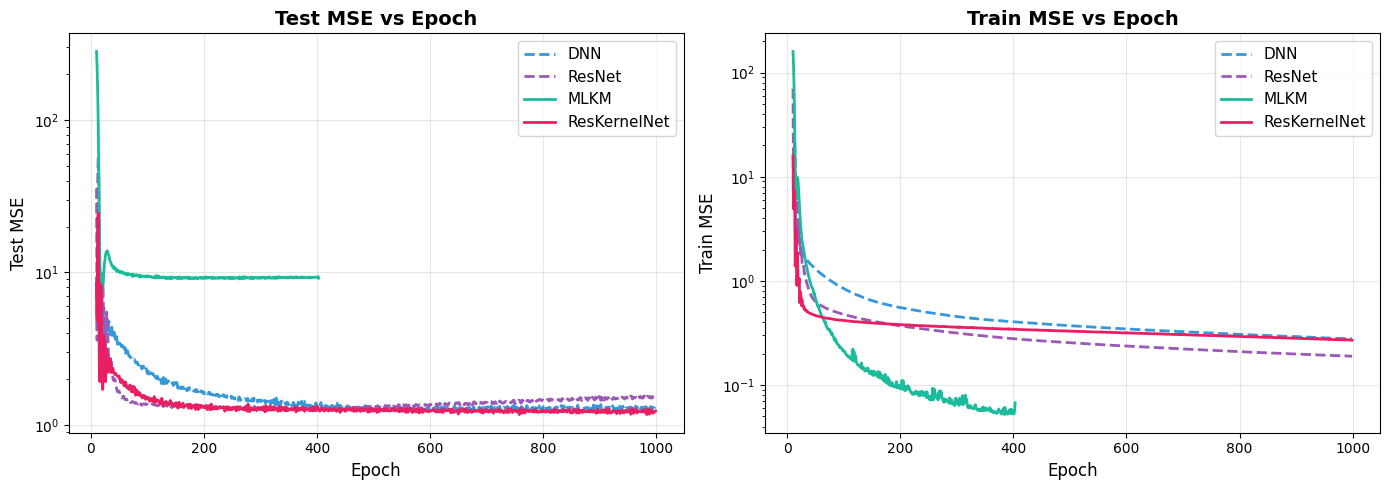


Figure saved as 'training_curves.png'

Epochs run: DNN=1000, ResNet=1000, MLKM=404, ResKernelNet=1000


In [24]:
# Training Curves: Epoch vs MSE for DNN, ResNet, MLKM, ResKernelNet

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define colors and styles
methods = {
    'DNN': {'train': dnn_trainloss, 'test': dnn_testloss, 'color': '#3498db', 'linestyle': '--'},
    'ResNet': {'train': res_trainloss, 'test': res_testloss, 'color': '#9b59b6', 'linestyle': '--'},
    'MLKM': {'train': mlkm_trainloss, 'test': mlkm_testloss, 'color': '#1abc9c', 'linestyle': '-'},
    'ResKernelNet': {'train': rkn_trainloss, 'test': rkn_testloss, 'color': '#e91e63', 'linestyle': '-'},
}

# Skip first N epochs to avoid initial large values
skip_epochs = 10

# Left plot: Test MSE
ax1 = axes[0]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['test']))
    ax1.plot(epochs, data['test'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Right plot: Train MSE
ax2 = axes[1]
for name, data in methods.items():
    epochs = range(skip_epochs, len(data['train']))
    ax2.plot(epochs, data['train'][skip_epochs:], 
             label=name, color=data['color'], linestyle=data['linestyle'], linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'training_curves.png'")
print(f"\nEpochs run: DNN={len(dnn_trainloss)}, ResNet={len(res_trainloss)}, MLKM={len(mlkm_trainloss)}, ResKernelNet={len(rkn_trainloss)}")


## Summary: All Methods Comparison


## Comprehensive Experiment: Different Hidden Dimensions

Test all models with different HIDDEN_DIM configurations (h1=h2=h3).

In [25]:
# =============================================
# Wrapper Function to Run All Models with Different Hidden Dims
# =============================================

def run_all_models_with_hidden_dim(h1, h2, h3, D_values=[100, 200, 300, 400, 500]):
    """
    Run all models with specified hidden dimensions.
    For MLKM/ResKernelNet, test multiple D values and return the best (lowest test MSE).
    
    Returns dict with results for each model including CPU memory usage.
    """
    global HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3
    
    # Update global hidden dimensions
    HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = h1, h2, h3
    
    results = {}
    
    # --- DNN ---
    start = time.time()
    dnn_result, dnn_cpu_mb, dnn_cpu_peak = measure_memory_cpu(
        lambda: run_dnn(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    dnn_time = time.time() - start
    # Unpack: train_mse, test_mse, epochs, net, optimizer, trainloss, testloss, device
    dnn_net, dnn_optimizer, dnn_trainloss, dnn_device = dnn_result[3], dnn_result[4], dnn_result[5], dnn_result[7]
    # Conformal prediction for DNN
    dnn_coverage, dnn_avg_len, _ = conformal_prediction_split(
        dnn_net, dnn_device,
        calibration_x, calibration_y, test_x, test_y
    )
    results['DNN'] = {
        'train_mse': dnn_result[0], 'test_mse': dnn_result[1], 
        'epochs': dnn_result[2], 'time': dnn_time, 'cpu_mb': dnn_cpu_mb, 'cpu_peak_mb': dnn_cpu_peak, 'best_D': None,
        'conformal_coverage': dnn_coverage, 'conformal_avg_len': dnn_avg_len
    }
    
    # --- ResNet ---
    start = time.time()
    resnet_result, resnet_cpu_mb, resnet_cpu_peak = measure_memory_cpu(
        lambda: run_resnet(train_x, train_y, test_x, test_y, **TRAINING_CONFIG)
    )
    resnet_time = time.time() - start
    # Unpack: train_mse, test_mse, epochs, net, optimizer, trainloss, testloss, device
    resnet_net, resnet_optimizer, resnet_trainloss, resnet_device = resnet_result[3], resnet_result[4], resnet_result[5], resnet_result[7]
    # Conformal prediction for ResNet
    resnet_coverage, resnet_avg_len, _ = conformal_prediction_split(
        resnet_net, resnet_device,
        calibration_x, calibration_y, test_x, test_y
    )
    results['ResNet'] = {
        'train_mse': resnet_result[0], 'test_mse': resnet_result[1],
        'epochs': resnet_result[2], 'time': resnet_time, 'cpu_mb': resnet_cpu_mb, 'cpu_peak_mb': resnet_cpu_peak, 'best_D': None,
        'conformal_coverage': resnet_coverage, 'conformal_avg_len': resnet_avg_len
    }
    
    # --- DKL ---
    start = time.time()
    dkl_result, dkl_cpu_mb, dkl_cpu_peak = measure_memory_cpu(
        lambda: run_dkl(train_x, train_y, test_x, test_y)
    )
    dkl_time = time.time() - start
    results['DKL'] = {
        'train_mse': dkl_result[0], 'test_mse': dkl_result[1],
        'epochs': 300, 'time': dkl_time, 'cpu_mb': dkl_cpu_mb, 'cpu_peak_mb': dkl_cpu_peak, 'best_D': None,
        'conformal_coverage': None, 'conformal_avg_len': None  # Not implemented for DKL
    }
    
    # --- DGP ---
    start = time.time()
    dgp_result, dgp_cpu_mb, dgp_cpu_peak = measure_memory_cpu(
        lambda: run_dgp(train_x, train_y, test_x, test_y)
    )
    dgp_time = time.time() - start
    results['DGP'] = {
        'train_mse': dgp_result[0], 'test_mse': dgp_result[1],
        'epochs': 1000, 'time': dgp_time, 'cpu_mb': dgp_cpu_mb, 'cpu_peak_mb': dgp_cpu_peak, 'best_D': None,
        'conformal_coverage': None, 'conformal_avg_len': None  # Not implemented for DGP
    }
    
    # --- MLKM (test all D values, pick best) ---
    best_mlkm = {'test_mse': float('inf')}
    best_mlkm_model = None  # Store model info for conformal prediction
    for D in D_values:
        start = time.time()
        # Use default argument D=D to capture current value (avoid closure issue)
        mlkm_result, mlkm_cpu_mb, mlkm_cpu_peak = measure_memory_cpu(
            lambda D=D: run_mlkm(train_x, train_y, test_x, test_y, D1=D, D2=D, D3=D, **TRAINING_CONFIG)
        )
        mlkm_time = time.time() - start
        if mlkm_result[1] < best_mlkm['test_mse']:
            best_mlkm = {
                'train_mse': mlkm_result[0], 'test_mse': mlkm_result[1],
                'epochs': mlkm_result[2], 'time': mlkm_time, 'cpu_mb': mlkm_cpu_mb, 'cpu_peak_mb': mlkm_cpu_peak, 'best_D': D
            }
            # Store model for conformal prediction (net, optimizer, trainloss, device)
            best_mlkm_model = (mlkm_result[3], mlkm_result[4], mlkm_result[5], mlkm_result[7])
    
    # Conformal prediction for MLKM (using best model)
    if best_mlkm_model:
        mlkm_net, mlkm_optimizer, mlkm_trainloss, mlkm_device = best_mlkm_model
        mlkm_coverage, mlkm_avg_len, _ = conformal_prediction_split(
            mlkm_net, mlkm_device,
            calibration_x, calibration_y, test_x, test_y
        )
        best_mlkm['conformal_coverage'] = mlkm_coverage
        best_mlkm['conformal_avg_len'] = mlkm_avg_len
    else:
        best_mlkm['conformal_coverage'] = None
        best_mlkm['conformal_avg_len'] = None
    results['MLKM'] = best_mlkm
    
    # --- ResKernelNet (test all D1 values, pick best) ---
    # Note: ResKernelNet has residual connections, so D2 must equal h1 and D3 must equal h2
    best_reskn = {'test_mse': float('inf')}
    best_reskn_model = None  # Store model info for conformal prediction
    for D in D_values:
        start = time.time()
        # Use default argument D=D to capture current value (avoid closure issue)
        reskn_result, reskn_cpu_mb, reskn_cpu_peak = measure_memory_cpu(
            lambda D=D: run_reskernelnet(train_x, train_y, test_x, test_y, 
                                         D1=D, D2=h1, D3=h2,
                                         **TRAINING_CONFIG)
        )
        reskn_time = time.time() - start
        if reskn_result[1] < best_reskn['test_mse']:
            best_reskn = {
                'train_mse': reskn_result[0], 'test_mse': reskn_result[1],
                'epochs': reskn_result[2], 'time': reskn_time, 'cpu_mb': reskn_cpu_mb, 'cpu_peak_mb': reskn_cpu_peak, 'best_D': D
            }
            # Store model for conformal prediction (net, optimizer, trainloss, device)
            best_reskn_model = (reskn_result[3], reskn_result[4], reskn_result[5], reskn_result[7])
    
    # Conformal prediction for ResKernelNet (using best model)
    if best_reskn_model:
        reskn_net, reskn_optimizer, reskn_trainloss, reskn_device = best_reskn_model
        reskn_coverage, reskn_avg_len, _ = conformal_prediction_split(
            reskn_net, reskn_device,
            calibration_x, calibration_y, test_x, test_y
        )
        best_reskn['conformal_coverage'] = reskn_coverage
        best_reskn['conformal_avg_len'] = reskn_avg_len
    else:
        best_reskn['conformal_coverage'] = None
        best_reskn['conformal_avg_len'] = None
    results['ResKernelNet'] = best_reskn
    
    return results


# =============================================
# Run Experiments with Different Hidden Dimensions
# =============================================


HIDDEN_DIM_CONFIGS = [[32, 64, 16],  [32, 128, 32], [32, 128, 16], [64, 128, 16], [64, 128, 32], [16, 32, 16], [16, 64, 32]]
D_VALUES = list(range(32, 320, 16))

# Store all results
all_hidden_dim_results = {}

print("=" * 80)
print("COMPREHENSIVE EXPERIMENT: All Models × Hidden Dimensions")
print("=" * 80)
print(f"Hidden dim configs [h1, h2, h3]: {HIDDEN_DIM_CONFIGS}")
print(f"D values for MLKM: {D_VALUES}")
print("=" * 80)

for h_config in tqdm(HIDDEN_DIM_CONFIGS, desc="Testing Hidden Dims"):
    h1, h2, h3 = h_config
    config_str = f"({h1},{h2},{h3})"
    print(f"\n--- Testing h1={h1}, h2={h2}, h3={h3} ---")

    results = run_all_models_with_hidden_dim(h1, h2, h3, D_VALUES)
    all_hidden_dim_results[config_str] = results
    
    for method, res in results.items():
        d_info = f" (D={res['best_D']})" if res['best_D'] else ""
        print(f"  {method}: Test MSE = {res['test_mse']:.4f}{d_info}")

# Restore original hidden dimensions
HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = 16, 64, 32

print("\n" + "=" * 80)
print("All experiments completed!")
print("=" * 80)

COMPREHENSIVE EXPERIMENT: All Models × Hidden Dimensions
Hidden dim configs [h1, h2, h3]: [[32, 64, 16], [32, 128, 32], [32, 128, 16], [64, 128, 16], [64, 128, 32], [16, 32, 16], [16, 64, 32]]
D values for MLKM: [32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304]


Testing Hidden Dims:   0%|          | 0/7 [00:00<?, ?it/s]


--- Testing h1=32, h2=64, h3=16 ---


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


0.20053414536259034
2.1675849188466616
1.2812553443334451
0.20053414536259034
2.273222840160923
1.7117047395906027
0.20053414536259034
2.708422257411652
2.2082503849943182
0.20053414536259034
3.253098130157019
2.2358491638009195
0.20053414536259034
3.217508994047622
2.4809779963467875
0.20053414536259034
3.574810580389392
3.03311114132826
0.20053414536259034
4.028016361636563
2.8382522746586574
0.20053414536259034
4.340199606783377
2.9731382524320193
0.20053414536259034
4.809186108353076
3.184798224524552
0.20053414536259034
4.802197079466242
3.440353638257115
0.20053414536259034
4.768788904025923
3.4735610748729187
0.20053414536259034
5.476917864006064
3.369104526880632
0.20053414536259034
6.006082607618087
3.476615400524135
0.20053414536259034
5.548599937365626
3.755045153221919
0.20053414536259034
5.975988313029445
4.055084688483362
0.20053414536259034
5.882604195764614
4.131704227362036
0.20053414536259034
5.416170232370105
4.350593473158984
0.20053414536259034
5.942654976620836
4.

...

  DNN: Test MSE = 1.3766
  ResNet: Test MSE = 1.4253
  DKL: Test MSE = 2.4960
  DGP: Test MSE = 2.3305
  MLKM: Test MSE = 1.7665 (D=48)
  ResKernelNet: Test MSE = 1.1060 (D=240)

--- Testing h1=16, h2=64, h3=32 ---


/Users/wanghd/Desktop/Research/Dai/Multi_layer_kernel_machines/Multi-Layer-Kernel-Machine/venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


0.20053414536259034
2.986071022563993
1.7787526298034912
0.20053414536259034
3.343737949420985
1.6224570225501997
0.20053414536259034
4.076627019412199
2.149924487273976
0.20053414536259034
4.850853429792381
2.161772268267976
0.20053414536259034
5.002513727240578
2.722323130458053
0.20053414536259034
5.659112986822771
2.626033702934633
0.20053414536259034
6.166951876895926
2.576463719742204
0.20053414536259034
6.599279930209038
2.9662141887995683
0.20053414536259034
6.934135582306622
3.0018513189150964
0.20053414536259034
7.105567336523092
3.4506758344909128
0.20053414536259034
7.563427612601173
3.372711360247844
0.20053414536259034
7.52220672830692
3.4971054780491193
0.20053414536259034
8.564421965097756
3.644838433772982
0.20053414536259034
7.804473936236661
3.9155013932141296
0.20053414536259034
8.768022363914055
3.910537852651863
0.20053414536259034
8.273509305590155
3.7825875130401405
0.20053414536259034
8.110638157383345
4.4152490774582756
0.20053414536259034
8.755271526970267
4.

Testing Hidden Dims: 100%|██████████| 7/7 [1:02:42<00:00, 537.50s/it]

  DNN: Test MSE = 1.3200
  ResNet: Test MSE = 1.4765
  DKL: Test MSE = 2.6967
  DGP: Test MSE = 2.3305
  MLKM: Test MSE = 1.7153 (D=48)
  ResKernelNet: Test MSE = 1.1505 (D=144)

All experiments completed!


In [26]:
# =============================================
# Results Summary: Hidden Dimension Comparison
# =============================================

# Convert results to DataFrame
rows = []
for config_str, methods in all_hidden_dim_results.items():
    for method, res in methods.items():
        rows.append({
            'Hidden Config': config_str,
            'Method': method,
            'Train MSE': res['train_mse'],
            'Test MSE': res['test_mse'],
            'Epochs': res['epochs'],
            'Time (s)': res['time'],
            'CPU Δ (MB)': res['cpu_mb'],
            'CPU Peak (MB)': res['cpu_peak_mb'],
            'Best D': res['best_D'],
            'Conformal Coverage': res.get('conformal_coverage'),
            'Conformal Avg Len': res.get('conformal_avg_len')
        })

hidden_dim_df = pd.DataFrame(rows)

# Display full results
print("=" * 100)
print("FULL RESULTS: All Models × Hidden Dimensions [h1, h2, h3]")
print("=" * 100)
display(hidden_dim_df.round(4))

# Pivot table: Test MSE
print("\n" + "=" * 100)
print("PIVOT TABLE: Test MSE (rows=Method, cols=Hidden Config)")
print("=" * 100)
pivot_test = hidden_dim_df.pivot(index='Method', columns='Hidden Config', values='Test MSE')
display(pivot_test.round(4))

# Best config per method
print("\n" + "=" * 100)
print("BEST CONFIGURATION FOR EACH METHOD")
print("=" * 100)
best_per_method = hidden_dim_df.loc[hidden_dim_df.groupby('Method')['Test MSE'].idxmin()]
display(best_per_method.sort_values('Test MSE').round(4))

# Best method per hidden config
print("\n" + "=" * 100)
print("BEST METHOD FOR EACH HIDDEN DIMENSION CONFIG")
print("=" * 100)
for config_str in all_hidden_dim_results.keys():
    subset = hidden_dim_df[hidden_dim_df['Hidden Config'] == config_str]
    best = subset.loc[subset['Test MSE'].idxmin()]
    d_info = f", D={int(best['Best D'])}" if pd.notna(best['Best D']) else ""
    print(f"  {config_str}: {best['Method']} (Test MSE: {best['Test MSE']:.4f}{d_info})")

# Save results
hidden_dim_df.to_csv(os.path.join(RESULTS_DIR, 'hidden_dim_comparison_results.csv'), index=False)
pivot_test.to_csv(os.path.join(RESULTS_DIR, 'hidden_dim_pivot_test_mse.csv'))
print(f"\nResults saved to: hidden_dim_comparison_results.csv, hidden_dim_pivot_test_mse.csv")

# =============================================
# Conformal Prediction Summary
# =============================================
print("\n" + "=" * 100)
print("CONFORMAL PREDICTION RESULTS (95% Coverage)")
print("=" * 100)

# Filter to methods with conformal prediction
conformal_methods = ['DNN', 'ResNet', 'MLKM', 'ResKernelNet']
conformal_df = hidden_dim_df[hidden_dim_df['Method'].isin(conformal_methods)].copy()

if not conformal_df.empty and 'Conformal Coverage' in conformal_df.columns:
    # Pivot table: Conformal Coverage
    print("\nPIVOT TABLE: Conformal Coverage (Target: 95%)")
    print("-" * 80)
    pivot_coverage = conformal_df.pivot(index='Method', columns='Hidden Config', values='Conformal Coverage')
    display(pivot_coverage.round(4))
    
    # Pivot table: Conformal Average Interval Length
    print("\nPIVOT TABLE: Conformal Average Interval Length (Lower is better)")
    print("-" * 80)
    pivot_avg_len = conformal_df.pivot(index='Method', columns='Hidden Config', values='Conformal Avg Len')
    display(pivot_avg_len.round(4))
    
    # Best conformal performance per method
    print("\n" + "=" * 100)
    print("BEST CONFORMAL PREDICTION RESULTS (by Coverage)")
    print("=" * 100)
    conformal_valid = conformal_df[conformal_df['Conformal Coverage'].notna()]
    if not conformal_valid.empty:
        best_conformal = conformal_valid.loc[conformal_valid.groupby('Method')['Conformal Coverage'].idxmax()]
        for _, row in best_conformal.iterrows():
            print(f"  {row['Method']} @ {row['Hidden Config']}: Coverage={row['Conformal Coverage']:.4f}, Avg Len={row['Conformal Avg Len']:.4f}")
else:
    print("No conformal prediction results available.")

FULL RESULTS: All Models × Hidden Dimensions [h1, h2, h3]


,Hidden Config,Method,Train MSE,Test MSE,Epochs,Time (s),CPU Δ (MB),CPU Peak (MB),Best D,Conformal Coverage,Conformal Avg Len
0,"(32,64,16)",DNN,0.1781,1.4986,1000,8.1425,0.2031,0.2344,NaN,0.5768,1.9526
1,"(32,64,16)",ResNet,0.1892,1.5272,1000,11.0507,-256.4375,0.3438,NaN,0.5929,2.0241
2,"(32,64,16)",DKL,0.0844,2.5849,300,7.9235,47.3750,47.3750,NaN,NaN,NaN
3,"(32,64,16)",DGP,0.1717,2.3305,1000,185.9906,219.4062,219.4062,NaN,NaN,NaN
4,"(32,64,16)",MLKM,0.2426,1.4150,170,2.5882,0.2188,0.2344,64.0,0.7101,2.2752
5,"(32,64,16)",ResKernelNet,0.2469,1.3291,1000,14.4734,-739.5781,0.0312,160.0,0.6329,2.1868
6,"(32,128,32)",DNN,0.1804,1.3868,1000,8.1465,-465.9062,0.4688,NaN,0.6468,1.9677
7,"(32,128,32)",ResNet,0.1591,1.4337,1000,11.6174,0.2031,0.2031,NaN,0.5594,1.8570
8,"(32,128,32)",DKL,0.0765,2.9125,300,6.1759,38.6875,38.6875,NaN,NaN,NaN
9,"(32,128,32)",DGP,0.1717,2.3305,1000,180.9563,191.7344,191.7344,NaN,NaN,NaN



PIVOT TABLE: Test MSE (rows=Method, cols=Hidden Config)


Hidden Config,"(16,32,16)","(16,64,32)","(32,128,16)","(32,128,32)","(32,64,16)","(64,128,16)","(64,128,32)"
Method,,,,,,,
DGP,2.3305,2.3305,2.3305,2.3305,2.3305,2.3305,2.3305
DKL,2.4960,2.6967,2.5719,2.9125,2.5849,4.8867,5.3200
DNN,1.3766,1.3200,1.2405,1.3868,1.4986,1.2526,1.4498
MLKM,1.7665,1.7153,2.1686,1.6084,1.4150,1.7135,1.9069
ResKernelNet,1.1060,1.1505,1.2105,1.1851,1.3291,1.1631,1.1463
ResNet,1.4253,1.4765,1.4703,1.4337,1.5272,1.3782,1.4055



BEST CONFIGURATION FOR EACH METHOD


...


BEST METHOD FOR EACH HIDDEN DIMENSION CONFIG
  (32,64,16): ResKernelNet (Test MSE: 1.3291, D=160)
  (32,128,32): ResKernelNet (Test MSE: 1.1851, D=48)
  (32,128,16): ResKernelNet (Test MSE: 1.2105, D=48)
  (64,128,16): ResKernelNet (Test MSE: 1.1631, D=64)
  (64,128,32): ResKernelNet (Test MSE: 1.1463, D=64)
  (16,32,16): ResKernelNet (Test MSE: 1.1060, D=240)
  (16,64,32): ResKernelNet (Test MSE: 1.1505, D=144)

Results saved to: hidden_dim_comparison_results.csv, hidden_dim_pivot_test_mse.csv

CONFORMAL PREDICTION RESULTS (95% Coverage)

PIVOT TABLE: Conformal Coverage (Target: 95%)
--------------------------------------------------------------------------------


Hidden Config,"(16,32,16)","(16,64,32)","(32,128,16)","(32,128,32)","(32,64,16)","(64,128,16)","(64,128,32)"
Method,,,,,,,
DNN,0.7065,0.6846,0.6919,0.6468,0.5768,0.6446,0.5958
MLKM,0.6679,0.7167,0.4945,0.6140,0.7101,0.6468,0.6082
ResKernelNet,0.7145,0.6438,0.7363,0.6621,0.6329,0.7298,0.7181
ResNet,0.6723,0.6249,0.6162,0.5594,0.5929,0.6213,0.5805



PIVOT TABLE: Conformal Average Interval Length (Lower is better)
--------------------------------------------------------------------------------


Hidden Config,"(16,32,16)","(16,64,32)","(32,128,16)","(32,128,32)","(32,64,16)","(64,128,16)","(64,128,32)"
Method,,,,,,,
DNN,2.1314,2.1143,2.0316,1.9677,1.9526,1.9607,1.9549
MLKM,2.4420,2.5682,1.9153,1.9403,2.2752,2.2522,2.0387
ResKernelNet,2.1844,2.1913,2.2221,2.0989,2.1868,2.2816,2.2757
ResNet,2.0667,2.0142,2.0395,1.8570,2.0241,2.0521,1.8701



BEST CONFORMAL PREDICTION RESULTS (by Coverage)
  DNN @ (16,32,16): Coverage=0.7065, Avg Len=2.1314
  MLKM @ (16,64,32): Coverage=0.7167, Avg Len=2.5682
  ResKernelNet @ (32,128,16): Coverage=0.7363, Avg Len=2.2221
  ResNet @ (16,32,16): Coverage=0.6723, Avg Len=2.0667


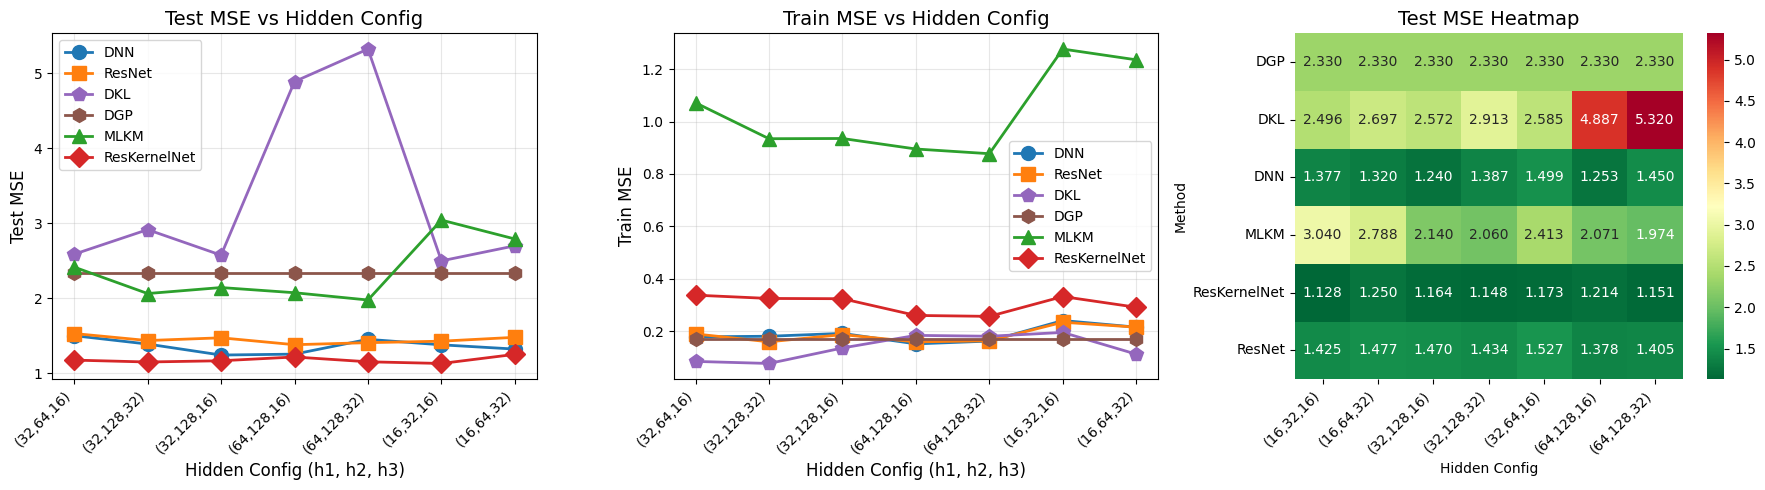

Plot saved to: hidden_dim_comparison_plots.png


In [ ]:
# =============================================
# Visualization: Hidden Dimension Comparison
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'DNN': '#1f77b4', 'ResNet': '#ff7f0e', 'DKL': '#9467bd', 'DGP': '#8c564b', 'MLKM': '#2ca02c', 'ResKernelNet': '#d62728'}
markers = {'DNN': 'o', 'ResNet': 's', 'DKL': 'p', 'DGP': 'h', 'MLKM': '^', 'ResKernelNet': 'D'}

config_labels = list(all_hidden_dim_results.keys())
x_positions = range(len(config_labels))

# Plot 1: Test MSE vs Hidden Config
ax1 = axes[0]
for method in colors.keys():
    data = hidden_dim_df[hidden_dim_df['Method'] == method]
    # Ensure order matches config_labels
    y_vals = [data[data['Hidden Config'] == cfg]['Test MSE'].values[0] for cfg in config_labels]
    ax1.plot(x_positions, y_vals, color=colors[method], 
             marker=markers[method], linewidth=2, markersize=10, label=method)
ax1.set_xlabel('Hidden Config (h1, h2, h3)', fontsize=12)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE vs Hidden Config', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(config_labels, rotation=45, ha='right')

# Plot 2: Train MSE vs Hidden Config
ax2 = axes[1]
for method in colors.keys():
    data = hidden_dim_df[hidden_dim_df['Method'] == method]
    y_vals = [data[data['Hidden Config'] == cfg]['Train MSE'].values[0] for cfg in config_labels]
    ax2.plot(x_positions, y_vals, color=colors[method],
             marker=markers[method], linewidth=2, markersize=10, label=method)
ax2.set_xlabel('Hidden Config (h1, h2, h3)', fontsize=12)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE vs Hidden Config', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(config_labels, rotation=45, ha='right')

# Plot 3: Heatmap
ax3 = axes[2]
sns.heatmap(pivot_test, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax3)
ax3.set_title('Test MSE Heatmap', fontsize=14)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hidden_dim_comparison_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to: hidden_dim_comparison_plots.png")

In [ ]:
# Create summary DataFrame with all results
results_summary = pd.DataFrame({
    'Method': ['RF+Ridge', 'DNN', 'ResNet', 'DKL', 'DGP', 'MLKM', 'ResKernelNet'],
    'Train MSE': [
        rf_train_mse, 
        dnn_train_mse, 
        res_train_mse, 
        dkl_train_mse, 
        dgp_train_mse, 
        mlkm_train_mse, 
        rkn_train_mse
    ],
    'Test MSE': [
        rf_test_mse, 
        dnn_test_mse, 
        res_test_mse, 
        dkl_test_mse, 
        dgp_test_mse, 
        mlkm_test_mse, 
        rkn_test_mse
    ],
    'Time (s)': [
        rf_time, 
        dnn_time, 
        res_time, 
        dkl_time, 
        dgp_time, 
        mlkm_time, 
        rkn_time
    ],
    'CPU Δ (MB)': [
        rf_delta_cpu_mb, 
        dnn_delta_cpu_mb, 
        res_delta_cpu, 
        dkl_delta_cpu, 
        dgp_delta_cpu, 
        mlkm_delta_cpu, 
        rkn_delta_cpu
    ],
    'CPU Peak (MB)': [
        rf_peak_cpu_mb,
        dnn_peak_cpu_mb,
        res_peak_cpu,
        dkl_peak_cpu,
        dgp_peak_cpu,
        mlkm_peak_cpu,
        rkn_peak_cpu
    ],
    'GPU Peak (MB)': [
        None,  # RF doesn't use GPU
        dnn_peak_gpu_mb, 
        res_peak_gpu, 
        dkl_peak_gpu, 
        dgp_peak_gpu, 
        mlkm_peak_gpu, 
        rkn_peak_gpu
    ]
})

# Display the summary table
print("=" * 80)
print("SUMMARY: All Methods Comparison on SML2010 Dataset")
print("=" * 80)
display(results_summary.round(4))

# Also show sorted by Test MSE
print("\n" + "=" * 80)
print("Ranked by Test MSE (lowest is best):")
print("=" * 80)
display(results_summary.sort_values('Test MSE').round(4))


SUMMARY: All Methods Comparison on SML2010 Dataset


,Method,Train MSE,Test MSE,Time (s),CPU Δ (MB),CPU Peak (MB),GPU Peak (MB)
0,RF+Ridge,0.1233,3.4459,0.5273,28.9844,28.9844,None
1,DNN,0.2772,1.2928,7.3232,0.6875,0.6875,None
2,ResNet,0.1892,1.5272,10.4109,-276.7031,0.3594,None
3,DKL,0.0844,2.5849,6.5460,37.4688,37.4688,None
4,DGP,0.1717,2.3305,211.4596,199.5938,199.5938,None
5,MLKM,3.5306,9.8335,28.4973,-187.5625,5.8750,None
6,ResKernelNet,0.2780,1.1913,18.4040,0.9375,0.9375,None



Ranked by Test MSE (lowest is best):


,Method,Train MSE,Test MSE,Time (s),CPU Δ (MB),CPU Peak (MB),GPU Peak (MB)
6,ResKernelNet,0.2780,1.1913,18.4040,0.9375,0.9375,None
1,DNN,0.2772,1.2928,7.3232,0.6875,0.6875,None
2,ResNet,0.1892,1.5272,10.4109,-276.7031,0.3594,None
4,DGP,0.1717,2.3305,211.4596,199.5938,199.5938,None
3,DKL,0.0844,2.5849,6.5460,37.4688,37.4688,None
0,RF+Ridge,0.1233,3.4459,0.5273,28.9844,28.9844,None
5,MLKM,3.5306,9.8335,28.4973,-187.5625,5.8750,None


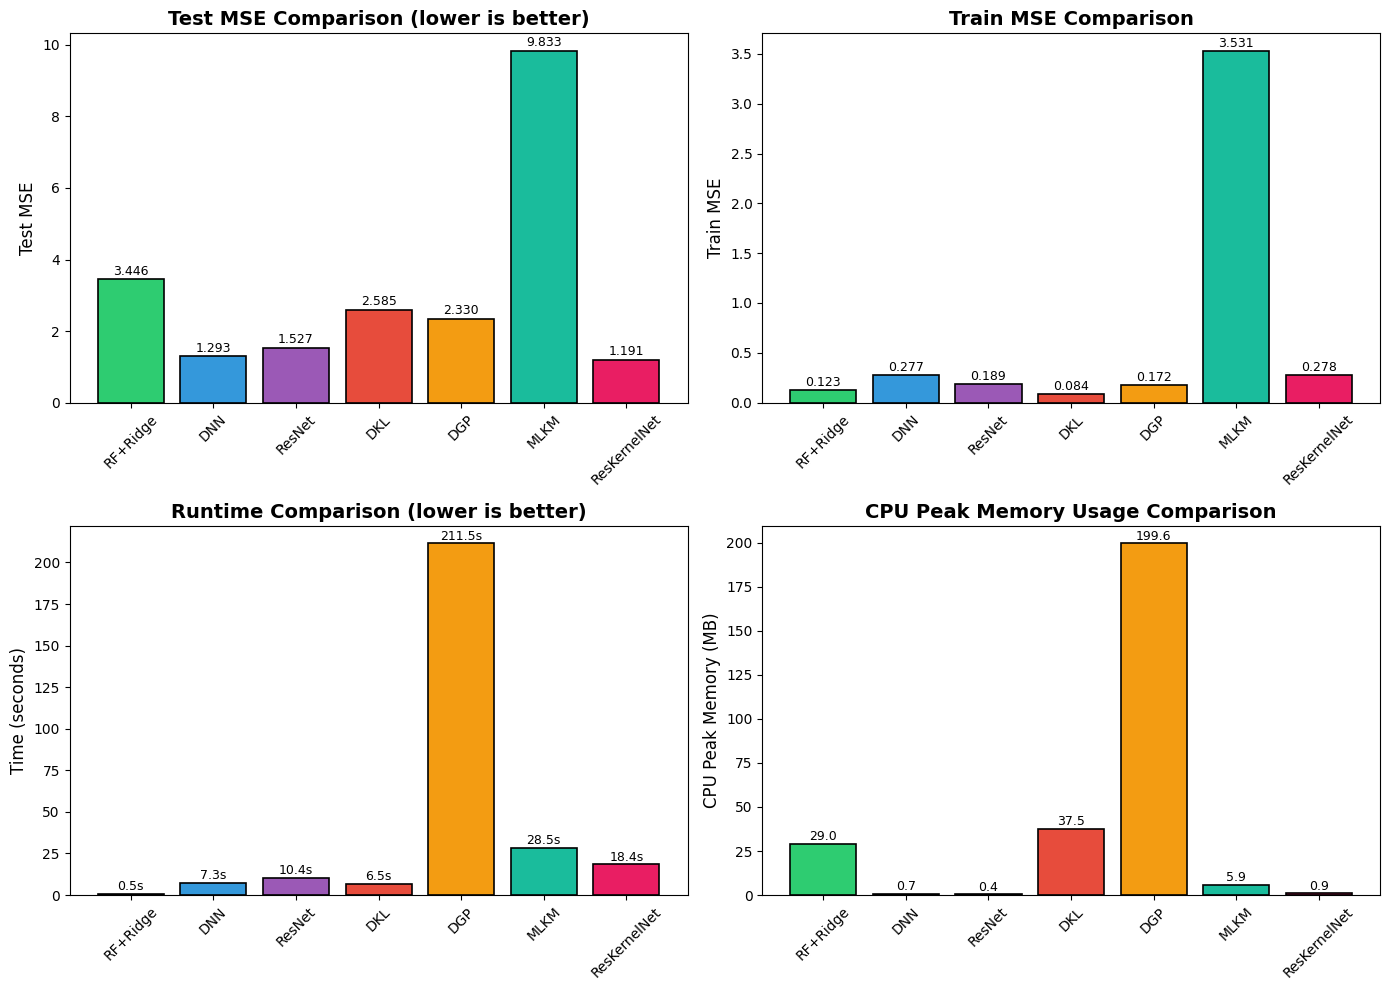


Figure saved as 'method_comparison.png'


In [ ]:
# Visualization: Bar Charts Comparing All Methods

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = results_summary['Method']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#e91e63']

# 1. Test MSE Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(methods, results_summary['Test MSE'], color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Test MSE', fontsize=12)
ax1.set_title('Test MSE Comparison (lower is better)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar, val in zip(bars1, results_summary['Test MSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Train MSE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(methods, results_summary['Train MSE'], color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Train MSE', fontsize=12)
ax2.set_title('Train MSE Comparison', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, results_summary['Train MSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 3. Runtime Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(methods, results_summary['Time (s)'], color=colors, edgecolor='black', linewidth=1.2)
ax3.set_ylabel('Time (seconds)', fontsize=12)
ax3.set_title('Runtime Comparison (lower is better)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, results_summary['Time (s)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

# 4. CPU Peak Memory Comparison
ax4 = axes[1, 1]
bars4 = ax4.bar(methods, results_summary['CPU Peak (MB)'], color=colors, edgecolor='black', linewidth=1.2)
ax4.set_ylabel('CPU Peak Memory (MB)', fontsize=12)
ax4.set_title('CPU Peak Memory Usage Comparison', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, val in zip(bars4, results_summary['CPU Peak (MB)']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'method_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'method_comparison.png'")


In [ ]:
# Best method summary
best_idx = results_summary['Test MSE'].idxmin()
best_method = results_summary.loc[best_idx]

print("=" * 60)
print("BEST PERFORMING METHOD (by Test MSE):")
print("=" * 60)
print(f"  Method:     {best_method['Method']}")
print(f"  Test MSE:   {best_method['Test MSE']:.6f}")
print(f"  Train MSE:  {best_method['Train MSE']:.6f}")
print(f"  Time:       {best_method['Time (s)']:.2f} seconds")
print(f"  CPU Δ:      {best_method['CPU Δ (MB)']:.2f} MB")
print(f"  CPU Peak:   {best_method['CPU Peak (MB)']:.2f} MB")
print("=" * 60)

# Efficiency metric: Test MSE per second of training
results_summary['Efficiency (MSE/s)'] = results_summary['Test MSE'] / results_summary['Time (s)']
print("\nEfficiency Analysis (Test MSE per second - lower is better):")
display(results_summary[['Method', 'Test MSE', 'Time (s)', 'Efficiency (MSE/s)']].sort_values('Efficiency (MSE/s)').round(4))


BEST PERFORMING METHOD (by Test MSE):
  Method:     ResKernelNet
  Test MSE:   1.191290
  Train MSE:  0.277984
  Time:       18.40 seconds
  CPU Δ:      0.94 MB
  CPU Peak:   0.94 MB

Efficiency Analysis (Test MSE per second - lower is better):


,Method,Test MSE,Time (s),Efficiency (MSE/s)
4,DGP,2.3305,211.4596,0.0110
6,ResKernelNet,1.1913,18.4040,0.0647
2,ResNet,1.5272,10.4109,0.1467
1,DNN,1.2928,7.3232,0.1765
5,MLKM,9.8335,28.4973,0.3451
3,DKL,2.5849,6.5460,0.3949
0,RF+Ridge,3.4459,0.5273,6.5345


comparison

MLKM Experiments with Different RFF Dimensions
Hidden layers: 32 -> 64 -> 16

--- Running MLKM with D1=D2=D3=16 ---
  Train MSE: 1.695729
  Test MSE:  8.796408
  Epochs:    1000
  Time (s):  6.20

--- Running MLKM with D1=D2=D3=32 ---
  Train MSE: 1.071553
  Test MSE:  2.413031
  Epochs:    1000
  Time (s):  7.18

--- Running MLKM with D1=D2=D3=48 ---
  Train MSE: 0.904020
  Test MSE:  2.742510
  Epochs:    1000
  Time (s):  7.28

--- Running MLKM with D1=D2=D3=64 ---
  Train MSE: 8.166218
  Test MSE:  22.957594
  Epochs:    175
  Time (s):  1.59

--- Running MLKM with D1=D2=D3=80 ---
  Train MSE: 0.935842
  Test MSE:  3.190301
  Epochs:    1000
  Time (s):  8.28

--- Running MLKM with D1=D2=D3=96 ---
  Train MSE: 0.931172
  Test MSE:  3.455840
  Epochs:    1000
  Time (s):  8.40

--- Running MLKM with D1=D2=D3=112 ---
  Train MSE: 0.877660
  Test MSE:  5.178434
  Epochs:    1000
  Time (s):  8.92

--- Running MLKM with D1=D2=D3=128 ---
  Train MSE: 1.083653
  Test MSE:  5.965767
  Epo

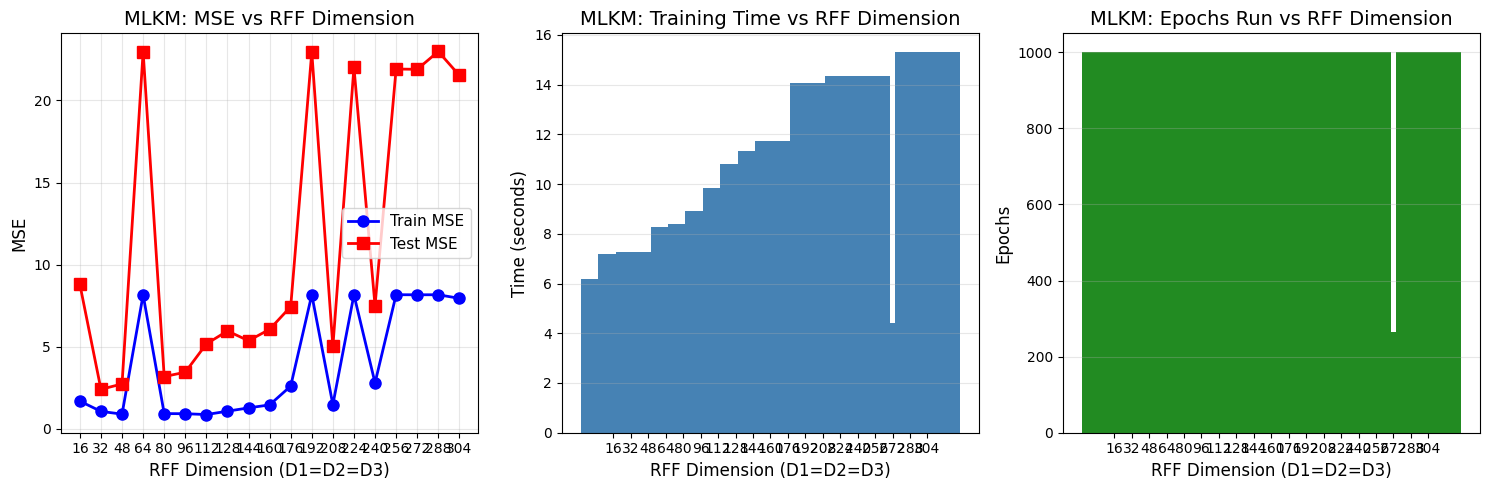


Plot saved to: mlkm_dimension_experiment_plots.png


In [ ]:
# =============================================
# Experiment: Test different RFF dimensions (D1=D2=D3)
# =============================================

HIDDEN_DIM1, HIDDEN_DIM2, HIDDEN_DIM3 = 32, 64, 16

D_values = list(range(16, 320, 16))

# Store results in a dictionary
mlkm_dimension_results = {
    'D': [],
    'train_mse': [],
    'test_mse': [],
    'epochs': [],
    'time': [],
    'cpu_delta_mb': [],
    'cpu_peak_mb': [],
    'gpu_peak_mb': []
}

print("=" * 60)
print("MLKM Experiments with Different RFF Dimensions")
print(f"Hidden layers: {HIDDEN_DIM1} -> {HIDDEN_DIM2} -> {HIDDEN_DIM3}")
print("=" * 60)

for D in D_values:
    print(f"\n--- Running MLKM with D1=D2=D3={D} ---")
    
    # Define core function with current D value
    def mlkm_core_d():
        return run_mlkm(train_x, train_y, test_x, test_y, D1=D, D2=D, D3=D, **TRAINING_CONFIG)
    
    # Clear memory before each run
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Run with timing and memory measurement
    ((result, peak_gpu), delta_cpu, peak_cpu), elapsed_time = measure_time(
        lambda: measure_memory_cpu(
            lambda: measure_memory_gpu(mlkm_core_d)
        )
    )
    
    # Unpack results
    train_mse, test_mse, epochs, net, optimizer, trainloss, testloss, device = result
    
    # Store results
    mlkm_dimension_results['D'].append(D)
    mlkm_dimension_results['train_mse'].append(train_mse)
    mlkm_dimension_results['test_mse'].append(test_mse)
    mlkm_dimension_results['epochs'].append(epochs)
    mlkm_dimension_results['time'].append(elapsed_time)
    mlkm_dimension_results['cpu_delta_mb'].append(delta_cpu)
    mlkm_dimension_results['cpu_peak_mb'].append(peak_cpu)
    mlkm_dimension_results['gpu_peak_mb'].append(peak_gpu)
    
    print(f"  Train MSE: {train_mse:.6f}")
    print(f"  Test MSE:  {test_mse:.6f}")
    print(f"  Epochs:    {epochs}")
    print(f"  Time (s):  {elapsed_time:.2f}")

print("\n" + "=" * 60)
print("All experiments completed!")
print("=" * 60)

# =============================================
# Display Results Summary Table
# =============================================
import pandas as pd

# Create DataFrame from results
results_df = pd.DataFrame(mlkm_dimension_results)
results_df.columns = ['D (RFF dim)', 'Train MSE', 'Test MSE', 'Epochs', 'Time (s)', 'CPU ΔMB', 'CPU Peak (MB)', 'GPU peak MB']

print("\n" + "=" * 80)
print("MLKM Results Summary: Different RFF Dimensions (D1=D2=D3)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Save results to CSV
results_csv_path = os.path.join(RESULTS_DIR, 'mlkm_dimension_experiment_results.csv')
results_df.to_csv(results_csv_path, index=False)
print(f"\nResults saved to: {results_csv_path}")

# =============================================
# Visualization: MSE vs RFF Dimension
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Train and Test MSE
ax1 = axes[0]
ax1.plot(mlkm_dimension_results['D'], mlkm_dimension_results['train_mse'], 'b-o', label='Train MSE', linewidth=2, markersize=8)
ax1.plot(mlkm_dimension_results['D'], mlkm_dimension_results['test_mse'], 'r-s', label='Test MSE', linewidth=2, markersize=8)
ax1.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('MLKM: MSE vs RFF Dimension', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(D_values)

# Plot 2: Training Time
ax2 = axes[1]
ax2.bar(mlkm_dimension_results['D'], mlkm_dimension_results['time'], color='steelblue', width=60)
ax2.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_title('MLKM: Training Time vs RFF Dimension', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(D_values)

# Plot 3: Number of Epochs
ax3 = axes[2]
ax3.bar(mlkm_dimension_results['D'], mlkm_dimension_results['epochs'], color='forestgreen', width=60)
ax3.set_xlabel('RFF Dimension (D1=D2=D3)', fontsize=12)
ax3.set_ylabel('Epochs', fontsize=12)
ax3.set_title('MLKM: Epochs Run vs RFF Dimension', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(D_values)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mlkm_dimension_experiment_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: mlkm_dimension_experiment_plots.png")

In [ ]:
dists = np.sum((train_x[None, :, :] - train_x[:, None, :])**2, axis=-1)
dists_flat = dists[np.triu_indices(len(train_x), k=1)]

median_sqdist = float(np.median(dists_flat))
sigma_median  = float(np.sqrt(median_sqdist))          # median Euclidean distance
gamma_median  = float(1.0 / sigma_median)      
gamma_median    

0.20053414536259034